<a href="https://colab.research.google.com/github/eparks8/ECGR-5105-Intro-to-ML/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 2: Standardization

## Imports

### Libraries

In [77]:
# Data Manipulation
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Google Drive Imports
from google.colab import drive

pd.set_option('future.no_silent_downcasting', True)

### Data

In [78]:
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/HW2/Housing.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [102]:
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
binary_map = {'yes':1, 'no':0}

df[binary_cols] = df[binary_cols].replace(binary_map).infer_objects(copy=False)

X = df.drop(['price','furnishingstatus'], axis=1)
X_5var = X.loc[:,['area', 'bedrooms', 'bathrooms', 'stories', 'parking']].copy()
X_11var = X.copy()
m = X.shape[0]
Y = df['price'].values

np.random.seed(0)

## Functions

In [80]:
def cost(X, Y, m, thetas, lam=0.):
  """
  Mean Squared Error cost function.

  Args:
    X (numpy.ndarray): Input features, including X0.
    Y (numpy.ndarray): Target values.
    m (int): Number of samples.
    thetas (numpy.ndarray): Numpy array of theta values.
    lam (float): Regularization parameter.

  Returns:
    cost (float): Mean Squared Error.
  """

  predictions = X.dot(thetas)
  errors = np.subtract(predictions,Y)
  return (1/(2*m))*(np.sum(np.square(errors))+lam*np.sum(np.square(thetas[1:])))

In [193]:
def gradient_descent(X_train, X_val, Y_train, Y_val, thetas, alpha, max_iters, delta, lam=0.):
  """
  Linear Regression with Gradient Descent.

  Args:
    X (numpy.ndarray): Input features, including X0.
    Y (numpy.ndarray): Target values.
    thetas (numpy.ndarray): Numpy array of theta values.
    alpha (float): Learning rate.
    max_iters (int): Maximum number of iterations.
    delta (float): Convergence threshold.

  Returns:
    train_history (numpy.ndarray): Training cost history.
    val_history (numpy.ndarray): Validation cost history.
    thetas (numpy.ndarray): Updated theta values.
  """

  thetas = np.array(thetas)
  m_train = X_train.shape[0] # Corrected: use training set size
  m_val = X_val.shape[0]     # Corrected: use validation set size
  train_history = []
  val_history = []

  # Loop for gradient descent iterations
  for k in range(max_iters):
    # Calculate current cost and append to history
    current_cost_train = cost(X_train, Y_train, m_train, thetas, lam)
    train_history.append(current_cost_train)
    current_cost_val = cost(X_val, Y_val, m_val, thetas, 0.)
    val_history.append(current_cost_val)

    # Check for convergence after the first iteration
    if k > 0:
      relative_change = abs(
        train_history[k-1] - train_history[k]
      ) / max(abs(train_history[k-1]), 1)

      if relative_change < delta:
        break

    train_predictions = X_train.dot(thetas)
    errors = np.subtract(train_predictions, Y_train)
    gradients = (1/m_train)*X_train.T.dot(errors)

    # Apply regularization to gradients for all features except the bias term (thetas[0])
    gradients[1:] = gradients[1:] + (lam/m_train) * thetas[1:]

    thetas = thetas - alpha*gradients

  return np.array(train_history), np.array(val_history), thetas

## Problem 1: Gradient Descent

### 1a (5 variables)

In [194]:
X_5v_train, X_5v_val, Y_train, Y_val = train_test_split(X_5var, Y, test_size=0.2, random_state=42)
X_5v_train = np.c_[np.ones(X_5v_train.shape[0]), X_5v_train]
X_5v_val = np.c_[np.ones(X_5v_val.shape[0]), X_5v_val]
train_history_5var, val_history_5var, theta_5var = gradient_descent(X_5v_train, X_5v_val, Y_train, Y_val, np.zeros(6), 0.01, 10000, 0.00001)

/tmp/ipykernel_7948/2365193321.py:18: RuntimeWarning: overflow encountered in square
  return (1/(2*m))*(np.sum(np.square(errors))+lam*np.sum(np.square(thetas[1:])))
/tmp/ipykernel_7948/2365193321.py:18: RuntimeWarning: invalid value encountered in scalar multiply
  return (1/(2*m))*(np.sum(np.square(errors))+lam*np.sum(np.square(thetas[1:])))
/tmp/ipykernel_7948/4276666710.py:47: RuntimeWarning: invalid value encountered in multiply
  gradients[1:] = gradients[1:] + (lam/m_train) * thetas[1:]


### 1b (11 variables)

In [195]:
X_11v_train, X_11v_val, Y_train, Y_val = train_test_split(X_11var, Y, test_size=0.2, random_state=42)
X_11v_train = np.c_[np.ones(X_11v_train.shape[0]), X_11v_train]
X_11v_val = np.c_[np.ones(X_11v_val.shape[0]), X_11v_val]
train_history_11var, val_history_11var, theta_11var = gradient_descent(X_11v_train, X_11v_val, Y_train, Y_val, np.zeros(12), 0.01, 10000, 0.00001)

/tmp/ipykernel_7948/2365193321.py:18: RuntimeWarning: overflow encountered in square
  return (1/(2*m))*(np.sum(np.square(errors))+lam*np.sum(np.square(thetas[1:])))
/tmp/ipykernel_7948/2365193321.py:18: RuntimeWarning: invalid value encountered in scalar multiply
  return (1/(2*m))*(np.sum(np.square(errors))+lam*np.sum(np.square(thetas[1:])))
/tmp/ipykernel_7948/4276666710.py:47: RuntimeWarning: invalid value encountered in multiply
  gradients[1:] = gradients[1:] + (lam/m_train) * thetas[1:]


### Comparison

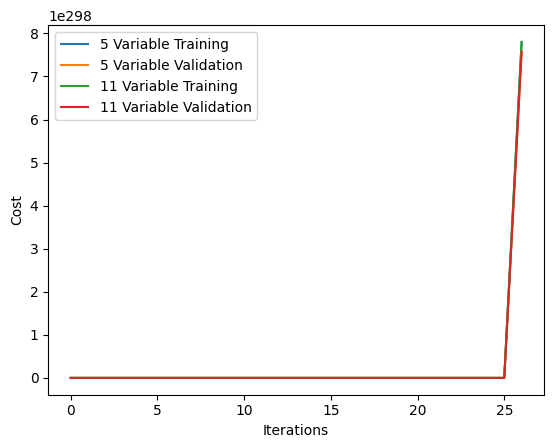

In [196]:
plt.plot(train_history_5var, label='5 Variable Training')
plt.plot(val_history_5var, label='5 Variable Validation')
plt.plot(train_history_11var, label='11 Variable Training')
plt.plot(val_history_11var, label='11 Variable Validation')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.legend()
plt.show()

## Problem 2: Normalized and Standardized Gradient Descent

In [197]:
min_max = MinMaxScaler()
standard = StandardScaler()

X_5v_train, X_5v_val, Y_5v_train, Y_5v_val = train_test_split(X_5var, Y, test_size=0.2, random_state=42)
X_5v_train_norm = min_max.fit_transform(X_5v_train.copy())
X_5v_val_norm = min_max.transform(X_5v_val.copy())
X_5v_train_norm = np.c_[np.ones(X_5v_train_norm.shape[0]), X_5v_train_norm]
X_5v_val_norm = np.c_[np.ones(X_5v_val_norm.shape[0]), X_5v_val_norm]
X_5v_train_std = standard.fit_transform(X_5v_train.copy())
X_5v_val_std = standard.transform(X_5v_val.copy())
X_5v_train_std = np.c_[np.ones(X_5v_train_std.shape[0]), X_5v_train_std]
X_5v_val_std = np.c_[np.ones(X_5v_val_std.shape[0]), X_5v_val_std]

X_11v_train, X_11v_val, Y_11v_train, Y_11v_val = train_test_split(X_11var, Y, test_size=0.2, random_state=42)
X_11v_train_norm = min_max.fit_transform(X_11v_train.copy())
X_11v_val_norm = min_max.transform(X_11v_val.copy())
X_11v_train_norm = np.c_[np.ones(X_11v_train_norm.shape[0]), X_11v_train_norm]
X_11v_val_norm = np.c_[np.ones(X_11v_val_norm.shape[0]), X_11v_val_norm]
X_11v_train_std = standard.fit_transform(X_11v_train.copy())
X_11v_val_std = standard.transform(X_11v_val.copy())
X_11v_train_std = np.c_[np.ones(X_11v_train_std.shape[0]), X_11v_train_std]
X_11v_val_std = np.c_[np.ones(X_11v_val_std.shape[0]), X_11v_val_std]

### 2a (5 variables)

#### Normalized

In [198]:
train_history_5var_norm, val_history_5var_norm, theta_5var_norm = gradient_descent(X_5v_train_norm, X_5v_val_norm, Y_5v_train, Y_5v_val, np.zeros(6), 0.01, 10000, 0.0001)

#### Standardized

In [199]:
train_history_5var_std, val_history_5var_std, theta_5var_std = gradient_descent(X_5v_train_std, X_5v_val_std, Y_5v_train, Y_5v_val, np.zeros(6), 0.01, 10000, 0.0001)

#### Comparison

5 Variable Normalized Final Loss:	 1410038581105.825
5 Variable Standardized Final Loss:	 1160054559626.641


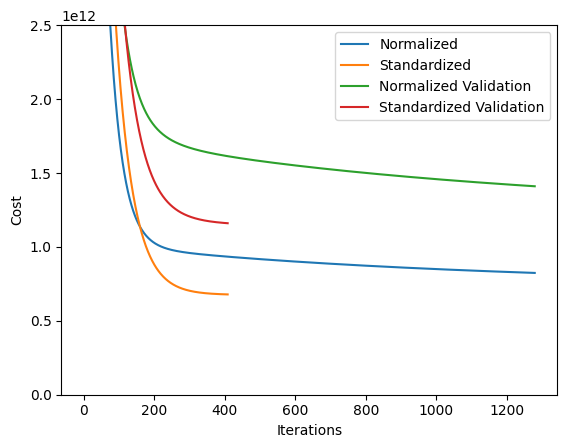

In [200]:
print(f"5 Variable Normalized Final Loss:\t {val_history_5var_norm[-1]:.3f}")
print(f"5 Variable Standardized Final Loss:\t {val_history_5var_std[-1]:.3f}")
plt.plot(train_history_5var_norm, label='Normalized')
plt.plot(train_history_5var_std, label='Standardized')
plt.plot(val_history_5var_norm, label='Normalized Validation')
plt.plot(val_history_5var_std, label='Standardized Validation')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.ylim(0, 2.5e12)
plt.legend()
plt.show()

### 2b (11 variables)

#### Normalized

In [201]:
train_history_11var_norm, val_history_11var_norm, theta_11var_norm = gradient_descent(X_11v_train_norm, X_11v_val_norm, Y_11v_train, Y_11v_val, np.zeros(12), 0.01, 10000, 0.0001)

#### Standardized

In [202]:
train_history_11var_std, val_history_11var_std, theta_11var_std = gradient_descent(X_11v_train_std, X_11v_val_std, Y_11v_train, Y_11v_val, np.zeros(12), 0.01, 10000, 0.0001)

#### Comparison

11 Variable Normalized Final Loss:	 1010390567225.072
11 Variable Standardized Final Loss:	 906104309357.274


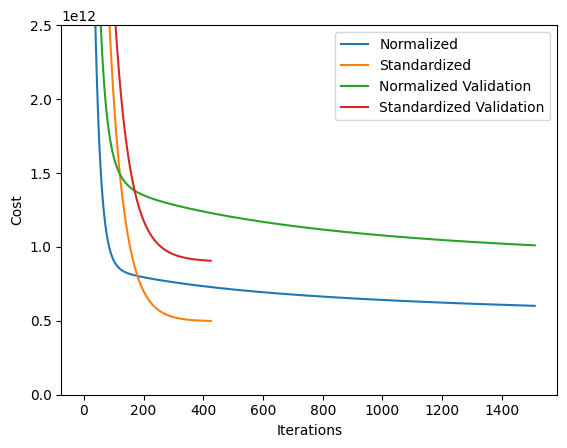

In [203]:
print(f"11 Variable Normalized Final Loss:\t {val_history_11var_norm[-1]:.3f}")
print(f"11 Variable Standardized Final Loss:\t {val_history_11var_std[-1]:.3f}")
plt.plot(train_history_11var_norm, label='Normalized')
plt.plot(train_history_11var_std, label='Standardized')
plt.plot(val_history_11var_norm, label='Normalized Validation')
plt.plot(val_history_11var_std, label='Standardized Validation')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.ylim(0, 2.5e12)
plt.legend()
plt.show()

## Problem 3: Penalized Gradient Descent
Includes both normalization and standardization. Compares against the best approach from Problem 2.

### 3a (5 variables)

#### Penalized

In [204]:
train_history_5var_pen, val_history_5var_pen, theta_5var_pen = gradient_descent(X_5v_train_norm, X_5v_val_norm, Y_5v_train, Y_5v_val, np.zeros(6), 0.01, 10000, 0.0001, lam=10.)

#### Comparison

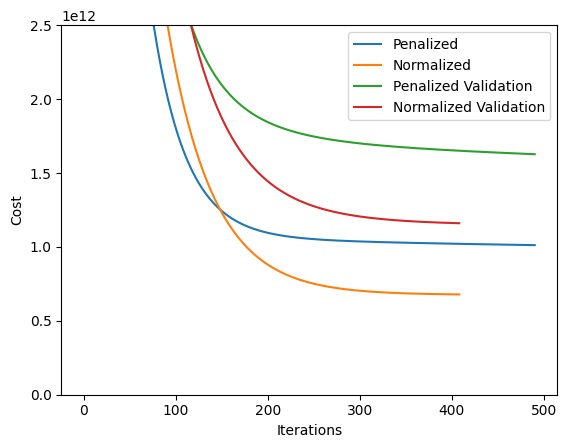

In [205]:
plt.plot(train_history_5var_pen, label='Penalized')
plt.plot(train_history_5var_std, label='Normalized')
plt.plot(val_history_5var_pen, label='Penalized Validation')
plt.plot(val_history_5var_std, label='Normalized Validation')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.ylim(0, 2.5e12)
plt.legend()
plt.show()

### 3b

#### Penalized

In [216]:
train_history_11var_pen, val_history_11var_pen, theta_11var_pen = gradient_descent(X_11v_train_norm, X_11v_val_norm, Y_11v_train, Y_11v_val, np.zeros(12), 0.01, 10000, 0.0001, lam=10.)

#### Comparison

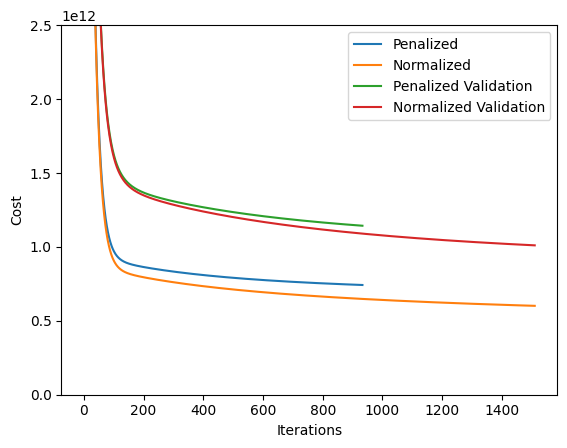

In [217]:
plt.plot(train_history_11var_pen, label='Penalized')
plt.plot(train_history_11var_norm, label='Normalized')
plt.plot(val_history_11var_pen, label='Penalized Validation')
plt.plot(val_history_11var_norm, label='Normalized Validation')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.ylim(0, 2.5e12)
plt.legend()
plt.show()